I have a theory that we are better at prediciting the first day when doing multiple days. 

# Setup

In [28]:
# Add project root to path so we can import from data_manipulation and model
import sys
from pathlib import Path

def _find_project_root():
    cwd = Path.cwd()
    if (cwd / "data_manipulation").is_dir():
        return cwd
    if (cwd.parent / "data_manipulation").is_dir():
        return cwd.parent
    return cwd  # fallback

project_root = _find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [29]:
import torch
from torch import nn, Tensor
import matplotlib.pyplot as plt
from functools import partial
import numpy as np


# Imports from data_manipulation and model
from data_manipulation.data_split import create_dataloader, DemandDataset
from model.functions import pinball_loss, rmse, train, get_test_loss, pinball_loss_tensor, pinball_loss_sum, normalize_batch, compute_mean_std

In [30]:
class simple_net(nn.Module):
    def __init__(self, input_dim: int, output_dim: int):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 80)
        self.fc2 = nn.Linear(80, 80)
        self.fc3 = nn.Linear(80, 80)
        self.fc4 = nn.Linear(80, output_dim)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x


In [31]:
all_specs = [
    "sales",
    "7_day_rolling_ema",	
    "30_day_rolling_ema",
    "90_day_rolling_ema",
    "30_day_rolling_min",
    "5_day_lag",
    "6_day_lag",
    "7_day_lag",
    "dif_180_day",
]

In [32]:
h_cost = 1
l_cost = 3
num_epochs = 500
max_horizon = 10

loss = partial(pinball_loss_sum, h_cost=h_cost, l_cost=l_cost)
og_loss = partial[Tensor](pinball_loss, h_cost=h_cost, l_cost=l_cost)

In [33]:
def get_test_loss_mod(
    net: torch.nn.Module,
    test_loader: torch.utils.data.DataLoader,
    loss: callable,
    device: str,
    horizon_idx: int = 0,
) -> list[float]:
    test_losses = []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            y_hat = net(x)
            test_loss = loss(y_hat[0, horizon_idx], y[0, horizon_idx])
            test_losses.append(test_loss.item())
    return test_losses

In [34]:
# Init data
data = {}

# Run the OG structure

In [35]:
# Get the data
train_loader_0, val_loader_0, test_loader_0 = create_dataloader(
    batch_size=8, 
    test_batch_size=1,
    pin_memory=False,
    data_mask=[("store", 1), ("item", 1)],
    specs=all_specs,
    days_to_predict=1
    )
input_dim = train_loader_0.dataset.x.shape[1]
output_dim = train_loader_0.dataset.y.shape[1]

# Get data for single day prediction
net_0 = simple_net(input_dim=input_dim, output_dim=output_dim)
optimizer = torch.optim.Adam(net_0.parameters(), lr=0.001)
_, _ = train(net_0, optimizer, loss, train_loader_0, val_loader_0, epochs=num_epochs, eval_interval=None, device="cpu", use_one_cycle_lr=True, use_tqdm=False)
test_loss = get_test_loss(net_0, test_loader_0, og_loss, "cpu")

data[1] = [
    test_loss, min(test_loss), max(test_loss), np.mean(test_loss)
]



# Test every other net

In [36]:
print(f"1 day prediction: Average loss: {np.mean(test_loss):.4f}, Min: {min(test_loss):.4f}, Max: {max(test_loss):.4f}")

for days in range(2, max_horizon):
    # Get data for spec
    train_loader, val_loader, test_loader = create_dataloader(
    batch_size=8, 
    test_batch_size=1,
    pin_memory=False,
    data_mask=[("store", 1), ("item", 1)],
    specs=all_specs,
    days_to_predict=days
    )
    input_dim = train_loader.dataset.x.shape[1]
    output_dim = train_loader.dataset.y.shape[1]

    # Get data for single day prediction
    net = simple_net(input_dim=input_dim, output_dim=output_dim)
    optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
    _, _ = train(net, optimizer, loss, train_loader, val_loader, epochs=num_epochs, eval_interval=None, device="cpu", use_one_cycle_lr=True, use_tqdm=False)
    test_loss = get_test_loss_mod(net, test_loader, og_loss, "cpu", horizon_idx=0)

    data[days] = [
    test_loss, min(test_loss), max(test_loss), np.mean(test_loss)
    ]
    print(f"{days} day prediction: Average loss: {np.mean(test_loss):.4f}, Min: {min(test_loss):.4f}, Max: {max(test_loss):.4f}")

1 day prediction: Average loss: 7.4714, Min: 0.0452, Max: 59.1908
2 day prediction: Average loss: 0.3411, Min: 0.0007, Max: 3.0096
3 day prediction: Average loss: 0.2285, Min: 0.0015, Max: 1.7454
4 day prediction: Average loss: 2.4833, Min: 0.0240, Max: 14.6905
5 day prediction: Average loss: 6.2602, Min: 0.1461, Max: 32.1960
6 day prediction: Average loss: 5.1309, Min: 0.0218, Max: 32.7471
7 day prediction: Average loss: 4.2337, Min: 0.0314, Max: 22.5027
8 day prediction: Average loss: 4.2001, Min: 0.0364, Max: 34.8475
9 day prediction: Average loss: 5.8731, Min: 0.0390, Max: 44.7136


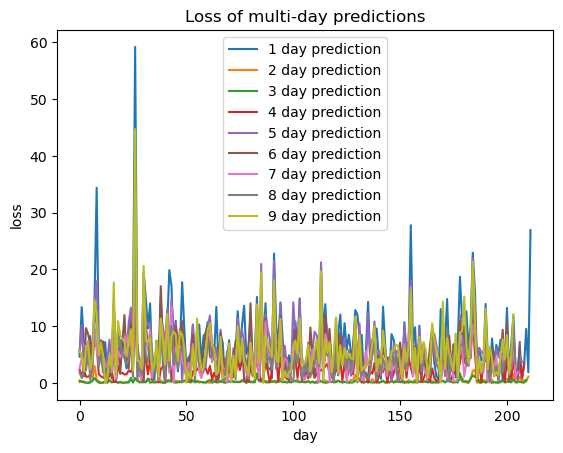

3 day prediction: Min: 0.0015, Max: 1.7454, Mean: 0.2285
2 day prediction: Min: 0.0007, Max: 3.0096, Mean: 0.3411
4 day prediction: Min: 0.0240, Max: 14.6905, Mean: 2.4833
8 day prediction: Min: 0.0364, Max: 34.8475, Mean: 4.2001
7 day prediction: Min: 0.0314, Max: 22.5027, Mean: 4.2337
6 day prediction: Min: 0.0218, Max: 32.7471, Mean: 5.1309
9 day prediction: Min: 0.0390, Max: 44.7136, Mean: 5.8731
5 day prediction: Min: 0.1461, Max: 32.1960, Mean: 6.2602
1 day prediction: Min: 0.0452, Max: 59.1908, Mean: 7.4714


In [37]:
for i in range(1, max_horizon):
    losses = np.asarray(data[i][0], dtype=float)
    plt.plot(np.arange(len(losses)), losses, label=f"{i} day prediction")

plt.xlabel("day")
plt.ylabel("loss")
plt.title("Loss of multi-day predictions")
plt.legend()
plt.show()

# Min / max / mean per horizon, printed in order of lowest → highest mean loss
_stats = []
for i in range(1, max_horizon):
    losses = np.asarray(data[i][0], dtype=float)
    _stats.append((float(np.mean(losses)), i, float(np.min(losses)), float(np.max(losses))))
_stats.sort(key=lambda t: t[0])
for mean_loss, i, mn, mx in _stats:
    print(f"{i} day prediction: Min: {mn:.4f}, Max: {mx:.4f}, Mean: {mean_loss:.4f}")




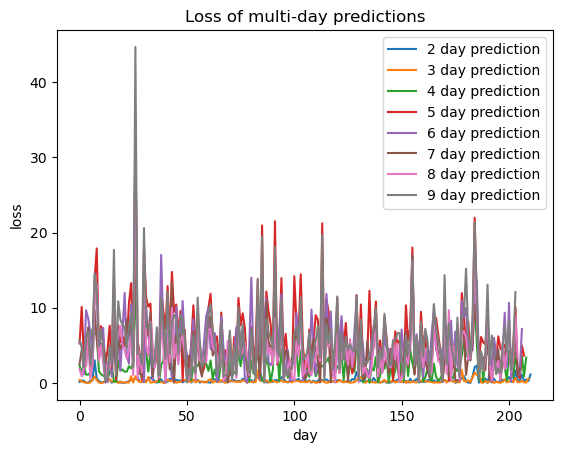

3 day prediction: Min: 0.0015, Max: 1.7454, Mean: 0.2285
2 day prediction: Min: 0.0007, Max: 3.0096, Mean: 0.3411
4 day prediction: Min: 0.0240, Max: 14.6905, Mean: 2.4833
8 day prediction: Min: 0.0364, Max: 34.8475, Mean: 4.2001
7 day prediction: Min: 0.0314, Max: 22.5027, Mean: 4.2337
6 day prediction: Min: 0.0218, Max: 32.7471, Mean: 5.1309
9 day prediction: Min: 0.0390, Max: 44.7136, Mean: 5.8731
5 day prediction: Min: 0.1461, Max: 32.1960, Mean: 6.2602


In [38]:
for i in range(2, max_horizon):
    losses = np.asarray(data[i][0], dtype=float)
    plt.plot(np.arange(len(losses)), losses, label=f"{i} day prediction")

plt.xlabel("day")
plt.ylabel("loss")
plt.title("Loss of multi-day predictions")
plt.legend()
plt.show()

# Min / max / mean per horizon, printed in order of lowest → highest mean loss
_stats = []
for i in range(2, max_horizon):
    losses = np.asarray(data[i][0], dtype=float)
    _stats.append((float(np.mean(losses)), i, float(np.min(losses)), float(np.max(losses))))
_stats.sort(key=lambda t: t[0])
for mean_loss, i, mn, mx in _stats:
    print(f"{i} day prediction: Min: {mn:.4f}, Max: {mx:.4f}, Mean: {mean_loss:.4f}")


